# GPU vs FPGA — Rate-Distortion Comparison

Compare inference quality of the **ResSHyp-relu** model family on GPU (W&B) and on FPGA (ZCU102).

**Data sources:**
- **GPU metrics** — fetched from the W&B project via the API (`test/bpp`, `test/psnr_merlin`, etc.)
- **FPGA metrics** — read from disk (`compiled_models/<name>/results/metrics.json`) after `batch_deploy.py`

**Structure:**
1. Setup & filters
2. Load GPU runs → tidy DataFrame
3. Load FPGA results → tidy DataFrame
4. Merge & coverage check
5. Aggregate statistics across seeds
6. RD-curve plots (GPU vs FPGA)
7. FPGA degradation Δ plot
8. BPP comparison (likelihood vs rANS bitstream)
9. Hamburg tile visualization
10. Save figures & per-λ summary table


## 1 · Setup & filters

In [38]:
import json
import sys
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from omegaconf import OmegaConf

ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR))

from src.utils.constants import AMP_LIN_99, EPS
from src.utils.metrics import psnr as _src_psnr
from src.utils.processing_utils import clip as clip_logI

# ── W&B project ────────────────────────────────────────────────────────────────
ENTITY = "cedric-leonard"
PROJECT = "SAR_DDC_FPGA"

# ── FPGA compiled models directory ─────────────────────────────────────────────
COMPILED_MODELS_DIR = ROOT_DIR / "results" / "fpga" / "compiled_models"

# ── Run filters (mirrors batch_deploy.py FILTERS_CONFIG) ───────────────────────
# Seeds 0-5 only; seed=42 is reserved for manual tests and excluded everywhere.
ACCEPTED_SEEDS = [0, 1, 2, 3, 4, 5]

FILTERS_CONFIG: List[Tuple] = [
    ("model.net.activation", "==", "relu"),
    ("model.net.no_output_padding", "==", True),
    ("seed", "in", ACCEPTED_SEEDS),
]

# ── Plotting style ──────────────────────────────────────────────────────────────
COLORS = {"gpu": "tab:blue", "fpga": "tab:orange"}
MARKERS = {"gpu": "o", "fpga": "s"}

# ── ANSI shortcuts ──────────────────────────────────────────────────────────────
r, g, b, y, e = "\033[31m", "\033[32m", "\033[34m", "\033[33m", "\033[0m"


## 2 · Load GPU runs → tidy DataFrame

Fetch all matching runs from W&B. One row per run (one `(lambda, seed)` pair).

**`groupby` primer** — `df.groupby("lambda")` splits the DataFrame into sub-groups by unique λ value,
returning a `GroupBy` object. Nothing is computed yet. `.agg(["mean","std"])` then applies each
aggregation to every column in each group, returning a new DataFrame with a two-level column index
`(metric, stat)`. Access: `stats_df[("bpp_gpu","mean")]` or equivalently `stats_df["bpp_gpu"]["mean"]`.

**Tidy / long format** — one row per `(lambda, seed, backend)`. This is the key design choice:
it makes aggregation, filtering, and plotting one-liners instead of nested loops.


In [39]:
def _check_condition(value: Any, op: str, test_value: Any) -> bool:
    """Single filter condition — mirrors batch_deploy.py / update_wandb_runs.py."""
    if op == "==":      return value == test_value
    if op == "!=":      return value != test_value
    if op == "in":      return value in test_value
    if op == "not in":  return value not in test_value
    if op == "exists":  return value is not None
    if op == "is_none": return value is None
    if op == ">":       return value is not None and float(value) > float(test_value)
    if op == "<":       return value is not None and float(value) < float(test_value)
    raise ValueError(f"Unsupported op: {op!r}")


def _run_matches(run_cfg: dict) -> bool:
    cfg = OmegaConf.create(run_cfg)
    return all(
        _check_condition(OmegaConf.select(cfg, key), op, val)
        for key, op, val in FILTERS_CONFIG
    )


def load_gpu_runs() -> pd.DataFrame:
    """Fetch matching W&B runs and return a tidy DataFrame (one row per run).

    Columns: lambda, seed, wandb_id, wandb_name, backend,
             bpp_likelihood, bpp_bitstream (NaN if not yet computed),
             psnr_merlin, psnr_adam_noc, mse_merlin, mse_adam_noc,
             ssim_merlin, ssim_adam_noc, ms_ssim_merlin, ms_ssim_adam_noc,
             run_dir  ← Hydra output directory (used to locate Hamburg tile .npy files)

    Notes:
    - bpp_bitstream comes from test/bpp_bitstream (added by update_wandb_runs.py once that
      pipeline is complete). Currently NaN for all runs — see cell 8 for the BPP comparison.
    - MERLIN_DDS metrics are included if present (they were added in a later evaluation pass).
    """
    api = wandb.Api()
    print(f"{b}Fetching runs from {ENTITY}/{PROJECT}...{e}")
    all_runs = list(api.runs(f"{ENTITY}/{PROJECT}"))
    matching = [r for r in all_runs if _run_matches(r.config)]
    print(f"  {len(all_runs)} total  →  {g}{len(matching)} match filters{e}")

    rows = []
    for run in matching:
        s = run.summary._json_dict
        # Extract Hydra run directory from config (nested under "paths")
        paths_cfg = run.config.get("paths", {})
        run_dir = paths_cfg.get("output_dir", "") if isinstance(paths_cfg, dict) else ""
        row: Dict[str, Any] = {
            "lambda":          run.config.get("lambda"),
            "seed":            run.config.get("seed"),
            "wandb_id":        run.id,
            "wandb_name":      run.name,
            "backend":         "gpu",
            # Path to the Hydra run directory (for Hamburg tile .npy / metrics.json lookups)
            "run_dir":         run_dir,
            # BPP — likelihood (always present) and bitstream (added later by update_wandb_runs.py)
            "bpp_likelihood":  s.get("test/bpp"),
            "bpp_bitstream":   s.get("test/bpp_bitstream"),  # NaN until update_wandb_runs finishes
            # Quality vs MERLIN reference
            "psnr_merlin":     s.get("test/psnr_merlin"),
            "mse_merlin":      s.get("test/mse_merlin"),
            "ssim_merlin":     s.get("test/ssim_merlin"),
            "ms_ssim_merlin":  s.get("test/ms_ssim_merlin"),
            # Quality vs ADAM-NOC reference
            "psnr_adam_noc":   s.get("test/psnr_adam_noc"),
            "mse_adam_noc":    s.get("test/mse_adam_noc"),
            "ssim_adam_noc":   s.get("test/ssim_adam_noc"),
            "ms_ssim_adam_noc":s.get("test/ms_ssim_adam_noc"),
        }
        rows.append(row)

    df = pd.DataFrame(rows).sort_values(["lambda", "seed"]).reset_index(drop=True)
    print(f"  Loaded {g}{len(df)}{e} GPU runs  ({df['lambda'].nunique()} λ × {df['seed'].nunique()} seeds)")
    return df


gpu_df = load_gpu_runs()
gpu_df.head(6)


Fetching runs from cedric-leonard/SAR_DDC_FPGA...
  260 total  →  60 match filters
  Loaded 60 GPU runs  (10 λ × 6 seeds)


,lambda,seed,wandb_id,wandb_name,backend,run_dir,bpp_likelihood,bpp_bitstream,psnr_merlin,mse_merlin,ssim_merlin,ms_ssim_merlin,psnr_adam_noc,mse_adam_noc,ssim_adam_noc,ms_ssim_adam_noc
0,1,0,0ppijrbl,ResSHyp-relu_0_merlinʎ1_lr5e-05_b12_no_out_pad,gpu,/mnt/vitisAI/Vitis-AI/DDC_FPGA/logs/train/sar_...,0.034741,0.035730,15.673816,16768.166016,0.841970,0.849233,17.523525,11579.838867,0.879035,0.877950
1,1,1,uub79nia,ResSHyp-relu_1_merlinʎ1_lr5e-05_b12_no_out_pad,gpu,/mnt/vitisAI/Vitis-AI/DDC_FPGA/logs/train/sar_...,0.036193,0.036851,15.500333,17365.314453,0.846775,0.855375,17.292614,12134.833008,0.883003,0.882985
2,1,2,2yt30gr7,ResSHyp-relu_2_merlinʎ1_lr5e-05_b12_no_out_pad,gpu,/mnt/vitisAI/Vitis-AI/DDC_FPGA/logs/train/sar_...,0.035846,0.036655,15.476408,17087.644531,0.843001,0.851736,17.262028,11846.408203,0.879570,0.879491
3,1,3,aqx4jwga,ResSHyp-relu_3_merlinʎ1_lr5e-05_b12_no_out_pad,gpu,/mnt/vitisAI/Vitis-AI/DDC_FPGA/logs/train/sar_...,0.017368,0.019254,12.176287,31376.712891,0.255705,0.097141,12.911790,26184.101562,0.252439,0.102006
4,1,4,7ra9kaea,ResSHyp-relu_4_merlinʎ1_lr5e-05_b12_no_out_pad,gpu,/mnt/vitisAI/Vitis-AI/DDC_FPGA/logs/train/sar_...,0.035596,0.036444,15.647723,16870.201172,0.848862,0.856756,17.484396,11679.206055,0.884722,0.884161
5,1,5,gl8ivopx,ResSHyp-relu_5_merlinʎ1_lr5e-05_b12_no_out_pad,gpu,/mnt/vitisAI/Vitis-AI/DDC_FPGA/logs/train/sar_...,0.016614,0.018287,12.160827,31431.500000,0.279401,0.102772,12.893044,26249.478516,0.276370,0.108465


## 3 · Load FPGA results → tidy DataFrame

Scan `compiled_models/` on disk. Each model directory is linked back to a W&B run via
`manifest.json` — first by `wandb_run_id` (present on runs deployed after the fix to
`deploy.py` today), then by `(seed, lambda)` lookup for the 60 existing runs.

**FPGA metrics available:** `bpp` (real rANS bitstream), `psnr` vs Noisy / ADAM / MERLIN.
No SSIM on FPGA yet — those columns are `NaN`. For a future implementation in pure NumPy,
see the comment at the bottom of this cell.


In [40]:
def _build_wandb_id_lookup(gpu_df: pd.DataFrame) -> Dict[Tuple, str]:
    """Build a (seed, lambda) -> wandb_id lookup from the already-loaded GPU DataFrame.

    Used as a fallback for manifests that predate the wandb_run_id field in manifest.json
    (i.e. the 60 runs deployed before today's deploy.py fix).
    The key (seed, lambda) is unique within the relu/no_output_padding filter set.
    """
    return {(row.seed, row["lambda"]): row.wandb_id for _, row in gpu_df.iterrows()}


def load_fpga_results(gpu_df: pd.DataFrame) -> pd.DataFrame:
    """Scan compiled_models/ and return a tidy DataFrame (one row per model with results).

    Filters: seed must be in ACCEPTED_SEEDS (excludes seed=42 and other manual runs).
    Links each FPGA result to a W&B run ID via manifest.json wandb_run_id if available,
    otherwise via (seed, lambda) lookup from gpu_df.

    FPGA metrics schema (from results/metrics.json):
        {"Noisy": {"bpp": ..., "mse": ..., "psnr": ...},
         "ADAM":  {"bpp": ..., "mse": ..., "psnr": ...},
         "MERLIN":{"bpp": ..., "mse": ..., "psnr": ...}}
    bpp is the same for all references (it's a property of the bitstream, not the reference).

    Note on SSIM/MS-SSIM:
        Not currently computed on FPGA because torchmetrics is unavailable there.
        Both metrics can be implemented in pure NumPy (scipy.ndimage.gaussian_filter for
        the local statistics) to within ~0.005 of torchmetrics values. Worth adding to
        inference_utils.py in a future pass.
    """
    wandb_lookup = _build_wandb_id_lookup(gpu_df)
    rows = []
    skipped = []

    for model_dir in sorted(COMPILED_MODELS_DIR.iterdir()):
        manifest_path = model_dir / "manifest.json"
        metrics_path  = model_dir / "results" / "metrics.json"

        if not manifest_path.exists():
            continue
        manifest = json.loads(manifest_path.read_text())

        seed   = manifest.get("seed")
        lmbda  = manifest.get("lambda")

        # Exclude seeds outside the accepted set (e.g. seed=42 manual runs)
        if seed not in ACCEPTED_SEEDS:
            skipped.append(model_dir.name)
            continue

        if not metrics_path.exists():
            print(f"  {y}WARNING{e}: no results/metrics.json for {model_dir.name} — skipping")
            continue

        metrics = json.loads(metrics_path.read_text())

        # Resolve W&B run ID: prefer manifest field (new deploys), fall back to lookup
        wandb_id = manifest.get("wandb_run_id") or wandb_lookup.get((seed, lmbda), "")

        row: Dict[str, Any] = {
            "lambda":          lmbda,
            "seed":            seed,
            "wandb_id":        wandb_id,
            "wandb_name":      manifest.get("model_name", model_dir.name),
            "backend":         "fpga",
            # Path to the compiled model directory (for Hamburg tile .npy / metrics.json lookups)
            "model_dir":       str(model_dir),
            # BPP from real rANS bitstream (all references share the same bpp)
            "bpp_likelihood":  float("nan"),  # not applicable for FPGA
            "bpp_bitstream":   metrics.get("MERLIN", {}).get("bpp"),
            # Quality vs MERLIN reference
            "psnr_merlin":     metrics.get("MERLIN", {}).get("psnr"),
            "mse_merlin":      metrics.get("MERLIN", {}).get("mse"),
            "ssim_merlin":     float("nan"),    # not yet computed on FPGA
            "ms_ssim_merlin":  float("nan"),
            # Quality vs ADAM-NOC reference
            "psnr_adam_noc":   metrics.get("ADAM", {}).get("psnr"),
            "mse_adam_noc":    metrics.get("ADAM", {}).get("mse"),
            "ssim_adam_noc":   float("nan"),
            "ms_ssim_adam_noc":float("nan"),
        }
        rows.append(row)

    df = pd.DataFrame(rows).sort_values(["lambda", "seed"]).reset_index(drop=True)
    if skipped:
        print(f"  Skipped {len(skipped)} models outside ACCEPTED_SEEDS: {skipped}")
    print(f"  Loaded {g}{len(df)}{e} FPGA results  ({df['lambda'].nunique()} λ × {df['seed'].nunique()} seeds)")
    no_link = df[df["wandb_id"] == ""]
    if len(no_link) > 0:
        print(f"  {y}WARNING{e}: {len(no_link)} FPGA results could not be linked to a W&B run ID:")
        for _, row in no_link.iterrows():
            print(f"    λ={row['lambda']} seed={row['seed']}  ({row['wandb_name']})")
    return df


fpga_df = load_fpga_results(gpu_df)
fpga_df.head(6)


  Skipped 1 models outside ACCEPTED_SEEDS: ['ResSHyp-relu_s42_L100_pt']
  Loaded 60 FPGA results  (10 λ × 6 seeds)


,lambda,seed,wandb_id,wandb_name,backend,model_dir,bpp_likelihood,bpp_bitstream,psnr_merlin,mse_merlin,ssim_merlin,ms_ssim_merlin,psnr_adam_noc,mse_adam_noc,ssim_adam_noc,ms_ssim_adam_noc
0,1,0,0ppijrbl,ResSHyp-relu_s0_L1_pt,fpga,/mnt/vitisAI/Vitis-AI/DDC_FPGA/results/fpga/co...,NaN,0.036790,21.751343,19134.177898,NaN,NaN,23.061105,12189.725459,NaN,NaN
1,1,1,uub79nia,ResSHyp-relu_s1_L1_pt,fpga,/mnt/vitisAI/Vitis-AI/DDC_FPGA/results/fpga/co...,NaN,0.037782,21.489034,18908.621425,NaN,NaN,22.784814,11944.669514,NaN,NaN
2,1,2,2yt30gr7,ResSHyp-relu_s2_L1_pt,fpga,/mnt/vitisAI/Vitis-AI/DDC_FPGA/results/fpga/co...,NaN,0.037421,21.242252,19778.070474,NaN,NaN,22.492386,12812.188643,NaN,NaN
3,1,3,aqx4jwga,ResSHyp-relu_s3_L1_pt,fpga,/mnt/vitisAI/Vitis-AI/DDC_FPGA/results/fpga/co...,NaN,0.019043,16.332437,31223.022701,NaN,NaN,16.566885,24453.616673,NaN,NaN
4,1,4,7ra9kaea,ResSHyp-relu_s4_L1_pt,fpga,/mnt/vitisAI/Vitis-AI/DDC_FPGA/results/fpga/co...,NaN,0.038701,21.680289,19088.880780,NaN,NaN,22.985273,12132.699572,NaN,NaN
5,1,5,gl8ivopx,ResSHyp-relu_s5_L1_pt,fpga,/mnt/vitisAI/Vitis-AI/DDC_FPGA/results/fpga/co...,NaN,0.018066,16.237755,31453.180223,NaN,NaN,16.462906,24688.175917,NaN,NaN


## 4 · Merge & coverage check

Concatenate GPU and FPGA rows into one DataFrame and verify we have both backends for
every `(lambda, seed)` pair. Missing combinations are shown explicitly.

**`pivot_table` primer** — reshapes long → wide: `index` defines rows, `columns` defines
the new column headers (here `backend`), `values` is the cell content. Think of it as a
spreadsheet cross-tab. Missing combinations appear as `NaN`.


In [41]:
# Merge both backends into a single tidy DataFrame
df = pd.concat([gpu_df, fpga_df], ignore_index=True)
df["lambda"] = df["lambda"].astype(float)
df["seed"]   = df["seed"].astype(int)
df = df.sort_values(["lambda", "seed", "backend"]).reset_index(drop=True)

print(f"Full DataFrame: {len(df)} rows ({df['backend'].value_counts().to_dict()})")
print(f"λ values: {sorted(df['lambda'].unique())}")
print(f"Seeds:    {sorted(df['seed'].unique())}")

# ── Coverage table ────────────────────────────────────────────────────────────
# pivot_table: rows=lambda, columns=backend, cells=count of runs present (should all be 6)
coverage = df.pivot_table(
    index="lambda", columns="backend", values="psnr_merlin", aggfunc="count"
).rename_axis(None, axis=1)

missing_gpu  = coverage[coverage["gpu"]  < len(ACCEPTED_SEEDS)] if "gpu"  in coverage else []
missing_fpga = coverage[coverage["fpga"] < len(ACCEPTED_SEEDS)] if "fpga" in coverage else []

print(f"\nCoverage (expected {len(ACCEPTED_SEEDS)} runs per λ per backend):")
print(coverage.to_string())
if len(missing_gpu):
    print(f"\n{y}WARNING: incomplete GPU coverage:{e}")
    print(missing_gpu)
if len(missing_fpga):
    print(f"\n{y}WARNING: incomplete FPGA coverage:{e}")
    print(missing_fpga)
else:
    print(f"\n{g}✓ Full coverage: all (λ, seed) pairs present on both backends.{e}")


Full DataFrame: 120 rows ({'fpga': 60, 'gpu': 60})
λ values: [1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0]
Seeds:    [0, 1, 2, 3, 4, 5]

Coverage (expected 6 runs per λ per backend):
        fpga  gpu
lambda           
1.0        6    6
2.0        6    6
5.0        6    6
10.0       6    6
20.0       6    6
50.0       6    6
100.0      6    6
200.0      6    6
500.0      6    6
1000.0     6    6

✓ Full coverage: all (λ, seed) pairs present on both backends.


## 5 · Aggregate statistics across seeds

`groupby(["lambda","backend"]).agg(...)` produces a DataFrame indexed by `(lambda, backend)` with a
two-level column `(metric, stat)`. This is the single source of truth for all plots below.

`query("backend == 'gpu'")` — pandas SQL-style row filter. Returns a view (not a copy), so it's
fast and readable. Equivalent to `df[df["backend"] == "gpu"]` but cleaner for compound conditions.


In [42]:
METRIC_COLS = [
    "bpp_likelihood", "bpp_bitstream",
    "psnr_merlin", "mse_merlin", "ssim_merlin", "ms_ssim_merlin",
    "psnr_adam_noc", "mse_adam_noc", "ssim_adam_noc", "ms_ssim_adam_noc",
]

# groupby + agg: for each (lambda, backend) group compute mean/std/min/max of every metric.
# Result is a DataFrame with MultiIndex columns: (metric_col, stat) e.g. ("psnr_merlin","mean").
stats_df = (
    df.groupby(["lambda", "backend"])[METRIC_COLS]
    .agg(["mean", "std", "min", "max"])
    .sort_index()  # sort by (lambda, backend)
)

# ── BPP column selection ──────────────────────────────────────────────────────
# Use bpp_bitstream if ALL runs (both backends) have it; else fall back to
# bpp_likelihood for GPU and bpp_bitstream for FPGA (they are not directly comparable
# but are the best available proxies per backend).
gpu_has_bitstream = df.query("backend == 'gpu'")["bpp_bitstream"].notna().all()
if gpu_has_bitstream:
    BPP_GPU_COL = "bpp_bitstream"
    print(f"{g}✓ All GPU runs have bpp_bitstream — using it for RD-curves.{e}")
else:
    BPP_GPU_COL = "bpp_likelihood"
    n_missing = df.query("backend == 'gpu'")["bpp_bitstream"].isna().sum()
    print(f"{y}⚠  {n_missing} GPU runs missing bpp_bitstream — using bpp_likelihood (soft entropy estimate).{e}")
    print("   Run update_wandb_runs.py to compute real bitstream BPP.")

BPP_FPGA_COL = "bpp_bitstream"  # always real rANS on FPGA
print(f"   GPU  BPP column : {BPP_GPU_COL}")
print(f"   FPGA BPP column : {BPP_FPGA_COL}")

# Quick preview: mean PSNR vs MERLIN at each λ for each backend
preview = stats_df["psnr_merlin"]["mean"].unstack("backend")
print("\nMean PSNR vs MERLIN across seeds:")
print(preview.to_string(float_format="{:.2f}".format))


✓ All GPU runs have bpp_bitstream — using it for RD-curves.
   GPU  BPP column : bpp_bitstream
   FPGA BPP column : bpp_bitstream

Mean PSNR vs MERLIN across seeds:
backend  fpga   gpu
lambda             
1.0     19.79 14.44
2.0     22.00 15.64
5.0     23.65 17.56
10.0    24.50 18.66
20.0    25.59 19.45
50.0    26.32 20.49
100.0   27.07 21.26
200.0   27.06 21.84
500.0   27.60 22.16
1000.0  28.32 22.19


## 6 · RD-curve plots — GPU vs FPGA

One curve per backend. Error band = min/max range across seeds. Error bars = ±1 std on BPP.

The X-axis uses `BPP_GPU_COL` for GPU (likelihood until `update_wandb_runs.py` finishes,
then switches automatically to bitstream) and always real rANS BPP for FPGA.
When both are bitstream BPP the curves are on a directly comparable x-axis.


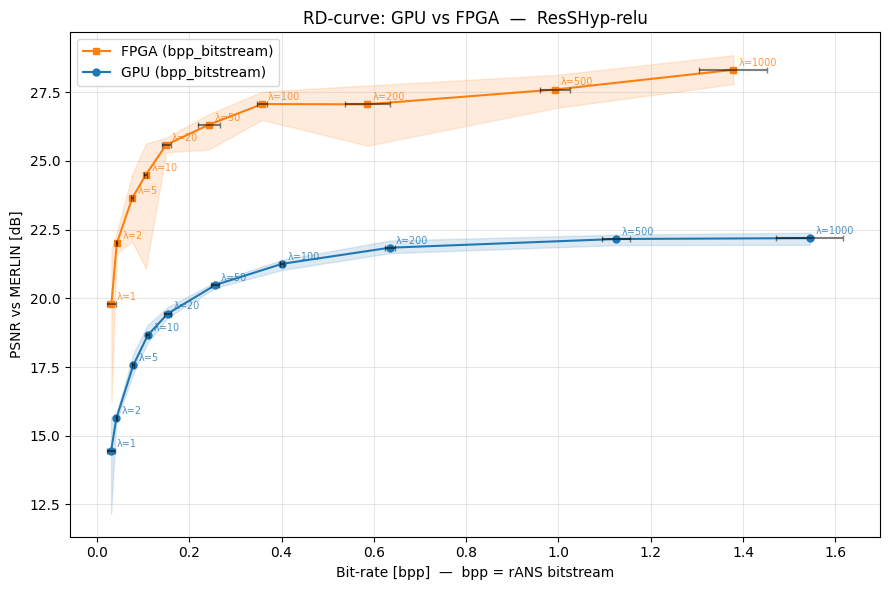

In [ ]:
def plot_rd_curve(
    ax: plt.Axes,
    stats: pd.DataFrame,
    backend: str,
    bpp_col: str,
    quality_col: str,
    label: Optional[str] = None,
    annotate_lambda: bool = False,
) -> None:
    """Plot a single RD curve (one backend) with error bands and BPP error bars.

    Args:
        stats:        stats_df already filtered to one backend (index = lambda values).
        backend:      "gpu" or "fpga" — used for color/marker lookup.
        bpp_col:      which BPP column to use on X axis.
        quality_col:  e.g. "psnr_merlin" — Y axis metric.
        annotate_lambda: if True, label each point with its λ value.
    """
    bpp_mean  = stats[(bpp_col, "mean")].astype(float)
    bpp_std   = stats[(bpp_col, "std")].astype(float).fillna(0)
    q_mean    = stats[(quality_col, "mean")].astype(float)
    q_min     = stats[(quality_col, "min")].astype(float)
    q_max     = stats[(quality_col, "max")].astype(float)

    # Sort by bpp for connected line
    order    = bpp_mean.argsort()
    bpp_s    = bpp_mean.iloc[order].values
    q_s      = q_mean.iloc[order].values
    q_min_s  = q_min.iloc[order].values
    q_max_s  = q_max.iloc[order].values
    bpp_std_s = bpp_std.iloc[order].values
    lambdas  = stats.index.get_level_values("lambda").to_numpy()[order]

    color  = COLORS[backend]
    marker = MARKERS[backend]
    lbl    = label or backend.upper()

    ax.plot(bpp_s, q_s, marker=marker, color=color, label=lbl, linewidth=1.5, markersize=5)
    ax.fill_between(bpp_s, q_min_s, q_max_s, alpha=0.15, color=color)
    ax.errorbar(bpp_s, q_s, xerr=bpp_std_s, fmt="none", ecolor="black", alpha=0.5, capsize=2)

    if annotate_lambda:
        for x, y, lam in zip(bpp_s, q_s, lambdas):
            ax.annotate(
                f"λ={int(lam)}", (x, y),
                textcoords="offset points", xytext=(4, 3), fontsize=7, color=color, alpha=0.8,
            )


def make_rd_figure(
    stats_df: pd.DataFrame,
    quality_col: str = "psnr_merlin",
    bpp_gpu_col: str = "bpp_likelihood",
    bpp_fpga_col: str = "bpp_bitstream",
    title_suffix: str = "",
    annotate_lambda: bool = False,
    save_path: Optional[Path] = None,
) -> plt.Figure:
    """Full RD-curve figure: GPU (blue) and FPGA (orange) on the same axes."""
    fig, ax = plt.subplots(figsize=(9, 6))

    for backend, bpp_col in [("fpga", bpp_fpga_col), ("gpu", bpp_gpu_col)]:
        # .xs() = cross-section: select all rows where the 'backend' level == backend
        # Returns a DataFrame whose index is now just 'lambda'.
        backend_stats = stats_df.xs(backend, level="backend")
        plot_rd_curve(
            ax, backend_stats, backend, bpp_col, quality_col,
            label=f"{backend.upper()} ({'bpp_bitstream' if 'bitstream' in bpp_col else 'bpp_likelihood'})",
            annotate_lambda=annotate_lambda,
        )

    ref_label = quality_col.split("_", 1)[1].replace("_", " ").upper()
    bpp_note = "bpp = likelihood (GPU) / rANS (FPGA)" if "likelihood" in bpp_gpu_col else "bpp = rANS bitstream"
    ax.set_xlabel(f"Bit-rate [bpp]  —  {bpp_note}")
    ax.set_ylabel(f"PSNR vs {ref_label} [dB]")
    ax.set_title(f"RD-curve: GPU vs FPGA  —  ResSHyp-relu {title_suffix}".strip())
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")
    return fig


# ── Main plot: PSNR vs MERLIN ─────────────────────────────────────────────────
fig_merlin = make_rd_figure(
    stats_df,
    quality_col="psnr_merlin",
    bpp_gpu_col=BPP_GPU_COL,
    annotate_lambda=True,
)
plt.show()


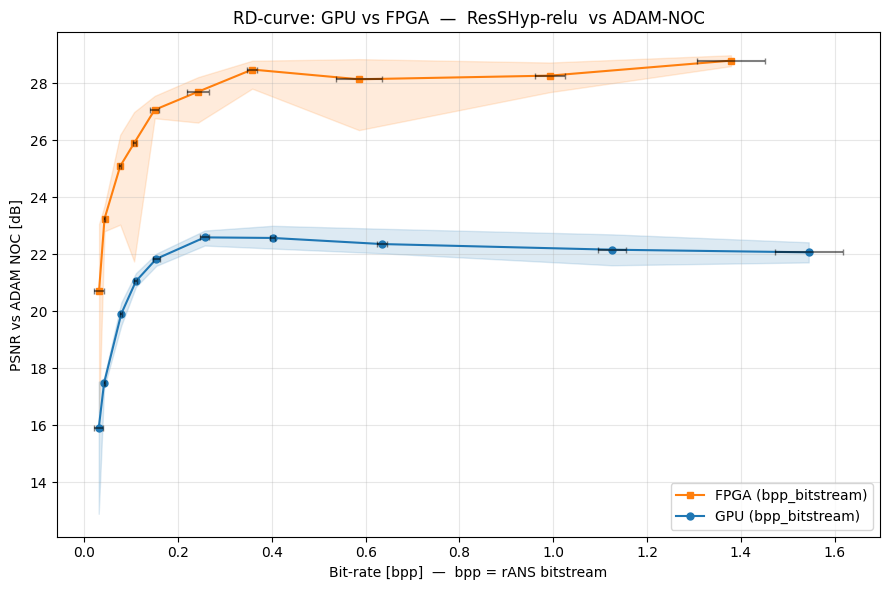

In [ ]:
# Optional: PSNR vs ADAM-NOC (uncomment to show)
fig_adam = make_rd_figure(
    stats_df,
    quality_col="psnr_adam_noc",
    bpp_gpu_col=BPP_GPU_COL,
    title_suffix="vs ADAM-NOC",
    annotate_lambda=True,
)
plt.show()


## 7 · FPGA degradation Δ plot

The key quantization question: **how much PSNR does the FPGA lose vs the GPU model?**

$$\Delta \text{PSNR}(\lambda) = \text{PSNR}_\text{FPGA}(\lambda) - \text{PSNR}_\text{GPU}(\lambda)$$

Computed per seed, then aggregated. A negative value means the FPGA is worse.
The error bands show the seed-to-seed variability of that degradation.

Note: when `BPP_GPU_COL == "bpp_likelihood"` the X-axis still shows GPU likelihood BPP
(since both backends are evaluated at the same λ, the X-axis here is just λ as a proxy).


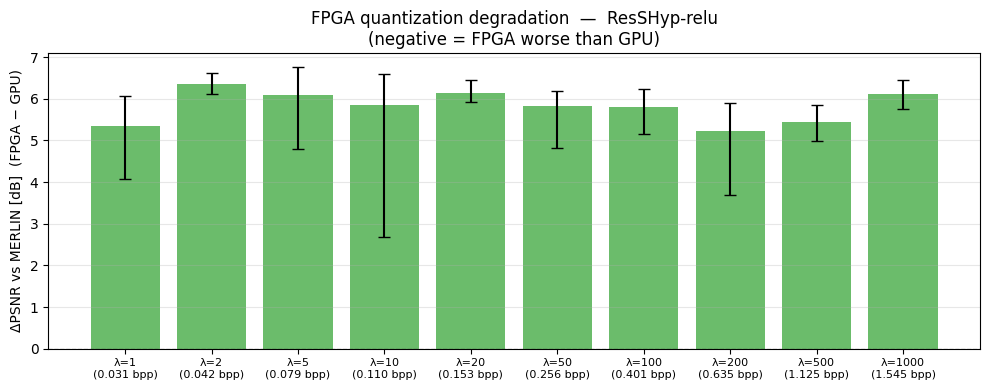


Mean FPGA degradation (PSNR vs MERLIN) across seeds:
        mean   std   min   max
lambda                        
1.0    5.350 0.961 4.077 6.078
2.0    6.357 0.221 6.127 6.619
5.0    6.083 0.875 4.792 6.759
10.0   5.847 1.551 2.689 6.604
20.0   6.144 0.216 5.923 6.455
50.0   5.831 0.530 4.823 6.177
100.0  5.813 0.360 5.164 6.235
200.0  5.219 0.833 3.692 5.890
500.0  5.439 0.332 4.985 5.845
1000.0 6.125 0.281 5.752 6.457


In [45]:
def compute_delta(df: pd.DataFrame, quality_col: str = "psnr_merlin") -> pd.DataFrame:
    """Compute per-seed FPGA - GPU delta for a quality metric, then aggregate.

    Uses pivot_table to align GPU and FPGA by (lambda, seed), then subtracts.
    Returns a DataFrame indexed by lambda with columns (delta, mean/std/min/max).
    """
    # pivot_table: rows=lambda×seed, columns=backend, values=quality_col
    # This gives one GPU value and one FPGA value per (lambda, seed) pair.
    pivot = df.pivot_table(index=["lambda", "seed"], columns="backend", values=quality_col)
    pivot = pivot.dropna(subset=["gpu", "fpga"])      # only pairs where both exist
    pivot["delta"] = pivot["fpga"] - pivot["gpu"]

    # Aggregate the delta across seeds for each lambda
    return (
        pivot["delta"]
        .groupby("lambda")
        .agg(["mean", "std", "min", "max"])
        .sort_index()
    )


def plot_delta(
    delta: pd.DataFrame,
    bpp_means: pd.Series,
    quality_col: str = "psnr_merlin",
    save_path: Optional[Path] = None,
) -> plt.Figure:
    """Bar chart of mean FPGA degradation per λ, with min/max error bars."""
    lambdas = delta.index.to_numpy().astype(float)
    means   = delta["mean"].to_numpy()
    mins    = delta["min"].to_numpy()
    maxs    = delta["max"].to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(lambdas))

    bars = ax.bar(x, means, color=["tab:red" if m < 0 else "tab:green" for m in means], alpha=0.7)
    ax.errorbar(x, means, yerr=[means - mins, maxs - means], fmt="none", color="black", capsize=4)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_xticks(x)
    ax.set_xticklabels([f"λ={int(l)}\n({bpp_means.get(l, float('nan')):.3f} bpp)" for l in lambdas], fontsize=8)
    ref_label = quality_col.split("_", 1)[1].replace("_", " ").upper()
    ax.set_ylabel(f"ΔPSNR vs {ref_label} [dB]  (FPGA − GPU)")
    ax.set_title(f"FPGA quantization degradation  —  ResSHyp-relu\n(negative = FPGA worse than GPU)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")
    return fig


delta_merlin = compute_delta(df, "psnr_merlin")

# Use GPU mean BPP as X-axis label (best available approximation per λ)
gpu_bpp_by_lambda = (
    df.query("backend == 'gpu'")
    .groupby("lambda")[BPP_GPU_COL]["mean"]
    if False  # placeholder; actual call below
    else df.query("backend == 'gpu'").groupby("lambda")[BPP_GPU_COL].mean()
)

fig_delta = plot_delta(delta_merlin, gpu_bpp_by_lambda, "psnr_merlin")
plt.show()

print("\nMean FPGA degradation (PSNR vs MERLIN) across seeds:")
print(delta_merlin[["mean", "std", "min", "max"]].to_string(float_format="{:.3f}".format))


## 8 · BPP comparison — likelihood vs rANS bitstream

The GPU trains with a soft entropy estimate (likelihood BPP from the entropy bottleneck).
The FPGA uses real rANS coding. This plot shows how they compare at each λ.

- **If `update_wandb_runs.py` has run and added `bpp_bitstream` to W&B**: both backends
  show hard BPP and the comparison is apples-to-apples.
- **Currently**: GPU shows likelihood BPP (soft, usually slightly lower than real coding)
  and FPGA shows rANS BPP. The gap is the coding overhead of the real entropy coder.

> To add `bpp_bitstream` to the GPU runs: complete `update_wandb_runs.py` and re-run cell 2.
> `BPP_GPU_COL` will automatically switch to `"bpp_bitstream"`.


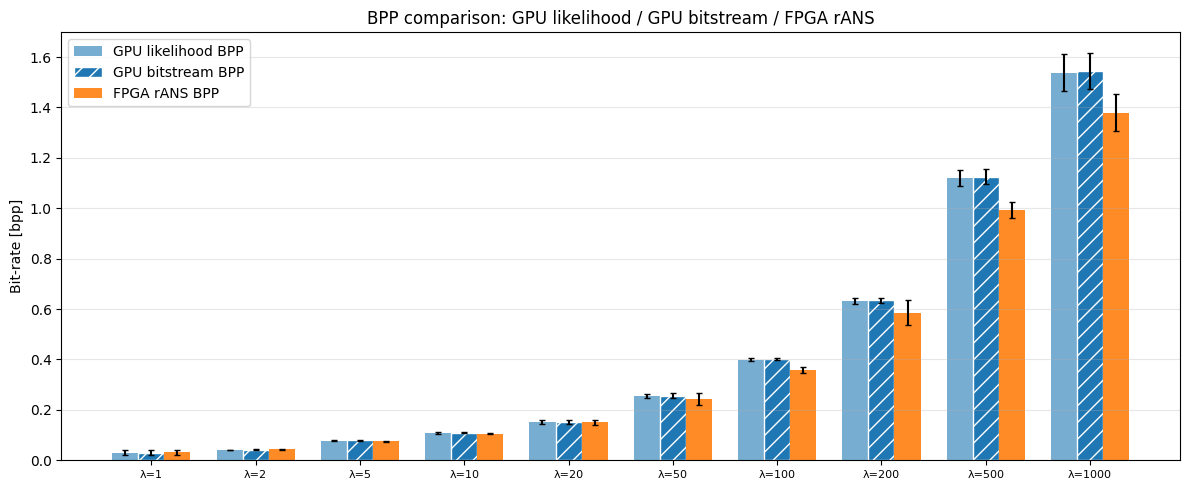

In [46]:
def plot_bpp_comparison(
    df: pd.DataFrame,
    save_path: Optional[Path] = None,
) -> plt.Figure:
    """Side-by-side grouped bar chart: GPU likelihood BPP vs FPGA rANS BPP per λ.

    Even when BPP_GPU_COL == "bpp_bitstream" this cell is useful: it compares the
    two backends' real BPP values to show any coding overhead difference.
    """
    # Aggregate BPP per (lambda, backend) — mean and std across seeds
    bpp_stats = df.groupby(["lambda", "backend"]).agg(
        bpp_gpu_lik_mean=("bpp_likelihood", "mean"),
        bpp_gpu_lik_std=("bpp_likelihood", "std"),
        bpp_bitstream_mean=("bpp_bitstream", "mean"),
        bpp_bitstream_std=("bpp_bitstream", "std"),
    )

    lambdas = sorted(df["lambda"].unique())
    x = np.arange(len(lambdas))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 5))

    gpu_lik_means, gpu_lik_stds = [], []
    gpu_bit_means, gpu_bit_stds = [], []
    fpga_means,    fpga_stds    = [], []

    for lam in lambdas:
        try:
            g_row = bpp_stats.loc[(lam, "gpu")]
            gpu_lik_means.append(g_row.get("bpp_gpu_lik_mean", float("nan")))
            gpu_lik_stds.append( g_row.get("bpp_gpu_lik_std",  0) or 0)
            gpu_bit_means.append(g_row.get("bpp_bitstream_mean", float("nan")))
            gpu_bit_stds.append( g_row.get("bpp_bitstream_std",  0) or 0)
        except KeyError:
            gpu_lik_means.append(float("nan")); gpu_lik_stds.append(0)
            gpu_bit_means.append(float("nan")); gpu_bit_stds.append(0)
        try:
            f_row = bpp_stats.loc[(lam, "fpga")]
            fpga_means.append(f_row.get("bpp_bitstream_mean", float("nan")))
            fpga_stds.append( f_row.get("bpp_bitstream_std",  0) or 0)
        except KeyError:
            fpga_means.append(float("nan")); fpga_stds.append(0)

    ax.bar(x - width, gpu_lik_means,  width, label="GPU likelihood BPP",  color="tab:blue",   alpha=0.6, yerr=gpu_lik_stds,  capsize=2)
    ax.bar(x,         gpu_bit_means,  width, label="GPU bitstream BPP",   color="tab:blue",   alpha=1.0, yerr=gpu_bit_stds,  capsize=2,
           hatch="//", edgecolor="white")
    ax.bar(x + width, fpga_means,     width, label="FPGA rANS BPP",       color="tab:orange", alpha=0.9, yerr=fpga_stds,     capsize=2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"λ={int(l)}" for l in lambdas], fontsize=8)
    ax.set_ylabel("Bit-rate [bpp]")
    ax.set_title("BPP comparison: GPU likelihood / GPU bitstream / FPGA rANS")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")
    return fig


fig_bpp = plot_bpp_comparison(df)
plt.show()


## 9 · Hamburg Tile Visualization

Visual comparison of the reconstructions on the **1024 × 1024 Hamburg tile** for GPU and FPGA
across all (or a user-selected subset of) λ values.

**Layout** — 3 rows × N columns (N = max(n\_refs, n\_lambdas)):
- **Row 0 — References**: Noisy, MERLIN; optionally ADAM-NOC and MERLIN-DDS (set flags below).
- **Row 1 — FPGA**: one subplot per λ. BPP from `Hamburg_*_metrics.json` (already saved by
  `inference_hybrid.py`).
- **Row 2 — GPU**: one subplot per λ. BPP from `recon_*_metrics.json` (saved by
  `CompareReconstructionToGT.on_test_end()` after re-running `update_wandb_runs.py`); shows `N/A`
  until that file exists.

All images are log-I, clipped to the **5th–95th percentile of the Noisy tile** (same reference
for every subplot → consistent brightness scale across the whole figure).

**PSNR note** — recomputed here on-the-fly from the `.npy` arrays using the same clip-first
formula as `inference_utils.MetricsTracker.compute_psnr` (clip both arrays to `AMP_LIN_99`
before MSE). This avoids inflated MSE from occasional GPU model output outliers.


Loaded 10 / 10 tiles  (seed=1, 5 λ × 2 backends)


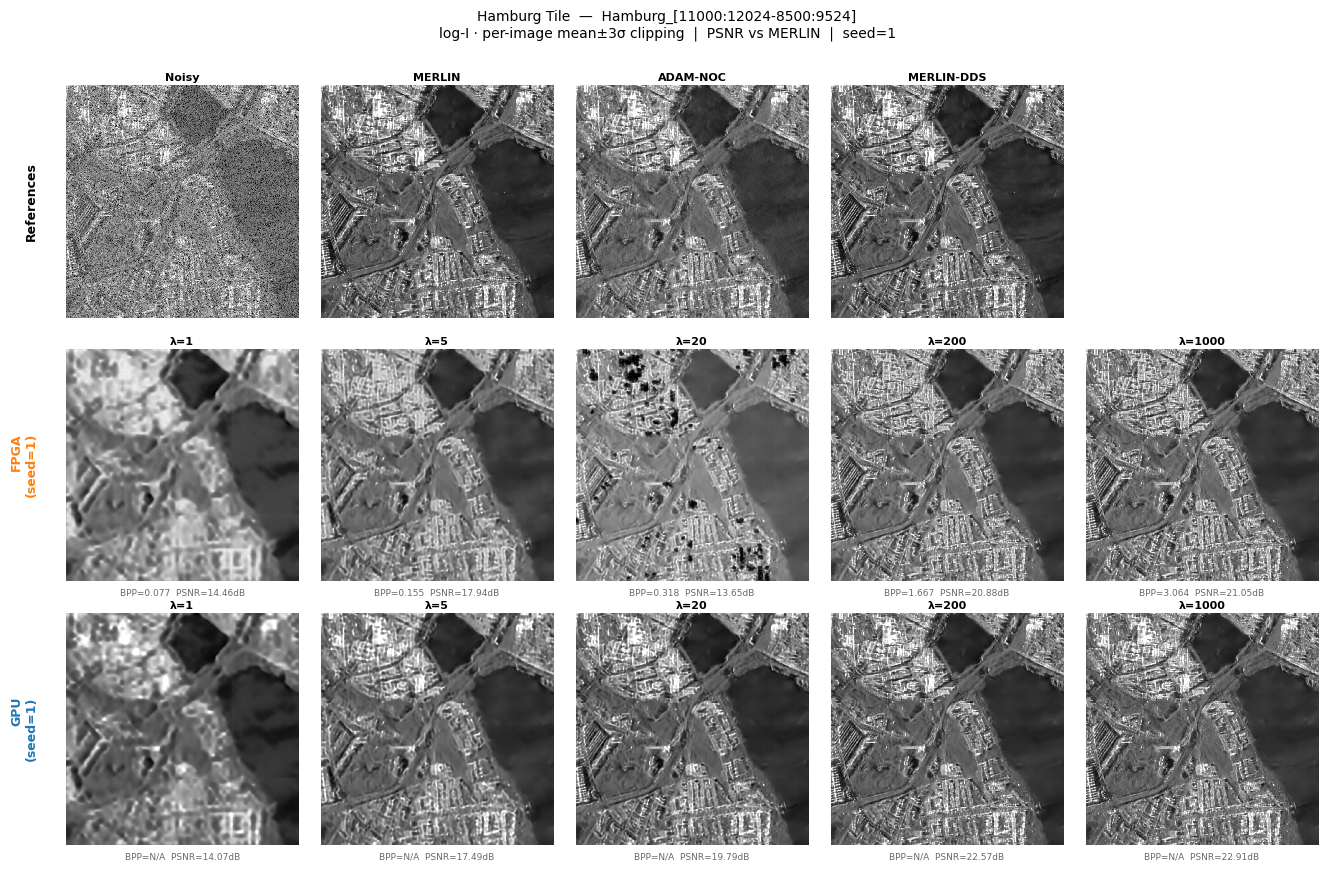

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# ── Configuration — edit these to change what is displayed ───────────────────
# ─────────────────────────────────────────────────────────────────────────────
TILE_NAME    = "Hamburg_[11000:12024-8500:9524]"
SHOW_LAMBDAS = [1, 5, 20, 200, 1000]      # None → all 10 lambdas; else list, e.g., [1, 20, 50, 200, 1000]
SEED_FOR_VIS = 1         # which seed's images to display

SHOW_ADAM_NOC   = True  # set True to add ADAM-NOC column in reference row
SHOW_MERLIN_DDS = True  # set True to add MERLIN-DDS column in reference row

REFS_DIR = ROOT_DIR / "data" / "visualization" / TILE_NAME


# ─────────────────────────────────────────────────────────────────────────────
# ── Helpers ───────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
def _linA_to_logI(linA: np.ndarray) -> np.ndarray:
    """Linear amplitude → log-intensity (same formula used throughout the project)."""
    return np.log(np.square(linA) + EPS)


def _compute_psnr_tile(recon: np.ndarray, ref: np.ndarray) -> float:
    """PSNR using src.utils.metrics.psnr — mse() already clips both to AMP_LIN_99 first."""
    r = torch.from_numpy(recon.astype(np.float32))
    t = torch.from_numpy(ref.astype(np.float32))
    return _src_psnr(r, t)


# ─────────────────────────────────────────────────────────────────────────────
# ── Load reference images ─────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
noisy_linA  = np.load(REFS_DIR / "linA_Noisy.npy")
merlin_linA = np.load(REFS_DIR / "linA_MERLIN.npy")
adam_noc_linA   = np.load(REFS_DIR / "linA_ADAM_NOC.npy")   if SHOW_ADAM_NOC   else None
merlin_dds_linA = np.load(REFS_DIR / "linA_MERLIN_DDS.npy") if SHOW_MERLIN_DDS else None

# ─────────────────────────────────────────────────────────────────────────────
# ── Load FPGA & GPU reconstructions for selected lambdas ─────────────────────
# ─────────────────────────────────────────────────────────────────────────────
sel_lambdas: List[float] = sorted(SHOW_LAMBDAS) if SHOW_LAMBDAS else sorted(df["lambda"].unique())

# tile_data[lmbda][backend] = {"linA", "logI", "psnr_merlin", "bpp"} or None if missing
tile_data: Dict[float, Dict[str, Optional[Dict]]] = {}

for lmbda in sel_lambdas:
    tile_data[lmbda] = {}
    for backend in ["fpga", "gpu"]:
        rows = df[
            (df["lambda"] == lmbda)
            & (df["seed"]   == SEED_FOR_VIS)
            & (df["backend"] == backend)
        ]
        if len(rows) == 0:
            tile_data[lmbda][backend] = None
            continue
        row = rows.iloc[0]

        # Paths differ per backend; columns run_dir / model_dir are NaN for the other backend
        if backend == "fpga":
            npy_path     = Path(row["model_dir"]) / "results" / f"{TILE_NAME}_recon_linA.npy"
            metrics_path = Path(row["model_dir"]) / "results" / f"{TILE_NAME}_metrics.json"
        else:
            npy_path     = Path(row["run_dir"]) / f"recon_{TILE_NAME}_linA.npy"
            metrics_path = Path(row["run_dir"]) / f"recon_{TILE_NAME}_metrics.json"

        if not npy_path.exists():
            print(f"  {y}MISSING{e}: λ={int(lmbda)} seed={SEED_FOR_VIS} {backend} — {npy_path.name}")
            tile_data[lmbda][backend] = None
            continue

        linA = np.load(npy_path)
        psnr_vs_merlin = _compute_psnr_tile(linA, merlin_linA)

        # BPP from per-tile metrics JSON: "bpp" for FPGA, "bpp_bitstream" for GPU
        bpp = float("nan")
        if metrics_path.exists():
            m = json.loads(metrics_path.read_text())
            bpp_key = "bpp" if backend == "fpga" else "bpp_bitstream"
            bpp = float(m.get(bpp_key, float("nan")))

        tile_data[lmbda][backend] = {
            "linA":        linA,
            "logI":        _linA_to_logI(linA),
            "psnr_merlin": psnr_vs_merlin,
            "bpp":         bpp,
        }

n_present = sum(1 for d in tile_data.values() for v in d.values() if v is not None)
print(f"Loaded {n_present} / {2 * len(sel_lambdas)} tiles  (seed={SEED_FOR_VIS}, {len(sel_lambdas)} λ × 2 backends)")

# ─────────────────────────────────────────────────────────────────────────────
# ── Plot ─────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
ref_panels: List[Tuple[str, np.ndarray]] = [("Noisy", noisy_linA), ("MERLIN", merlin_linA)]
if adam_noc_linA   is not None: ref_panels.append(("ADAM-NOC",   adam_noc_linA))
if merlin_dds_linA is not None: ref_panels.append(("MERLIN-DDS", merlin_dds_linA))

n_refs = len(ref_panels)
n_lam  = len(sel_lambdas)
n_cols = max(n_refs, n_lam)
n_rows = 3
SUBPLOT_IN = 2.6   # inches per subplot

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(SUBPLOT_IN * n_cols + 0.5, SUBPLOT_IN * n_rows + 0.7),
    squeeze=False,
)

# ── Row header annotations (text on transAxes, visible even after axis("off")) ──
_ROW_HEADERS = [
    (0, "References",                "black"),
    (1, f"FPGA\n(seed={SEED_FOR_VIS})", COLORS["fpga"]),
    (2, f"GPU\n(seed={SEED_FOR_VIS})",  COLORS["gpu"]),
]
for ri, label, color in _ROW_HEADERS:
    axes[ri, 0].text(
        -0.12, 0.5, label,
        transform=axes[ri, 0].transAxes,
        rotation=90, va="center", ha="right",
        fontsize=9, fontweight="bold", color=color,
    )


def _show(ax: plt.Axes, logI: np.ndarray, title: str,
          subtitle: Optional[str] = None, border_color: Optional[str] = None) -> None:
    """Display a clipped log-I image with optional border + subtitle.

    Clipping: mean ± 3·std applied per-image (mirrors CompareReconstructionToGT callback).
    """
    clipped = clip_logI(logI, mean_std_norm=True, clip_factor=3)
    ax.imshow(clipped, cmap="gray", aspect="equal", interpolation="none")
    ax.set_title(title, fontsize=8, fontweight="bold", pad=3)
    if subtitle:
        ax.text(0.5, -0.03, subtitle, transform=ax.transAxes,
                fontsize=6.5, ha="center", va="top", color="dimgray")
    ax.axis("off")
    if border_color:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.0)


# ── Row 0: References ─────────────────────────────────────────────────────────
for ci, (ref_name, ref_linA) in enumerate(ref_panels):
    _show(axes[0, ci], _linA_to_logI(ref_linA), ref_name)
for ci in range(n_refs, n_cols):
    axes[0, ci].axis("off")

# ── Rows 1 (FPGA) & 2 (GPU) ──────────────────────────────────────────────────
for row_idx, backend in enumerate(["fpga", "gpu"], start=1):
    color = COLORS[backend]
    for ci, lmbda in enumerate(sel_lambdas):
        data = tile_data.get(lmbda, {}).get(backend)
        if data is None:
            axes[row_idx, ci].axis("off")
            axes[row_idx, ci].text(0.5, 0.5, "N/A", ha="center", va="center",
                                   transform=axes[row_idx, ci].transAxes, fontsize=10, color="gray")
            continue
        bpp_str  = f"{data['bpp']:.3f}" if not np.isnan(data["bpp"]) else "N/A"
        subtitle = f"BPP={bpp_str}  PSNR={data['psnr_merlin']:.2f}dB"
        _show(axes[row_idx, ci], data["logI"], f"λ={int(lmbda)}", subtitle, border_color=color)
    for ci in range(n_lam, n_cols):
        axes[row_idx, ci].axis("off")

fig.suptitle(
    f"Hamburg Tile  —  {TILE_NAME}\n"
    f"log-I · per-image mean±3σ clipping  |  PSNR vs MERLIN  |  seed={SEED_FOR_VIS}",
    fontsize=10, y=1.01,
)
plt.tight_layout(h_pad=1.2, w_pad=0.3)
plt.show()


## 10 · Save figures & per-λ summary table

Optional: save all figures to `results/plots/` and export a CSV summary.


In [48]:
SAVE_FIGURES = False   # set True to write PNGs to results/plots/
PLOTS_DIR = ROOT_DIR / "results" / "plots"

if SAVE_FIGURES:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    make_rd_figure(
        stats_df, quality_col="psnr_merlin", bpp_gpu_col=BPP_GPU_COL,
        annotate_lambda=True, save_path=PLOTS_DIR / "rd_curve_gpu_vs_fpga_merlin.png",
    )
    plot_delta(delta_merlin, gpu_bpp_by_lambda, "psnr_merlin",
               save_path=PLOTS_DIR / "fpga_degradation_merlin.png")
    plot_bpp_comparison(df, save_path=PLOTS_DIR / "bpp_comparison.png")
    print(f"Figures saved to {PLOTS_DIR}")

# ── Per-λ summary table ───────────────────────────────────────────────────────
# Flatten MultiIndex columns for a readable CSV.
# .xs() selects a cross-section: here all rows for a given backend level.
summary_rows = []
for lam in sorted(df["lambda"].unique()):
    for backend in ["gpu", "fpga"]:
        try:
            s = stats_df.xs(backend, level="backend").loc[lam]
        except KeyError:
            continue
        summary_rows.append({
            "lambda":             lam,
            "backend":            backend,
            "bpp_mean":           s.get((BPP_GPU_COL if backend == "gpu" else "bpp_bitstream", "mean")),
            "bpp_std":            s.get((BPP_GPU_COL if backend == "gpu" else "bpp_bitstream", "std")),
            "psnr_merlin_mean":   s.get(("psnr_merlin", "mean")),
            "psnr_merlin_std":    s.get(("psnr_merlin", "std")),
            "psnr_adam_noc_mean": s.get(("psnr_adam_noc", "mean")),
            "psnr_adam_noc_std":  s.get(("psnr_adam_noc", "std")),
        })

summary_df = pd.DataFrame(summary_rows)
print("Per-λ summary (means across seeds):")
print(summary_df.to_string(index=False, float_format="{:.4f}".format))

# save_path = ROOT_DIR / "data" / "RD-curve_results" / "gpu_vs_fpga_relu.csv"
# summary_df.to_csv(save_path, index=False)
# print(f"\nSaved: {save_path}")


Per-λ summary (means across seeds):
   lambda backend  bpp_mean  bpp_std  psnr_merlin_mean  psnr_merlin_std  psnr_adam_noc_mean  psnr_adam_noc_std
   1.0000     gpu    0.0305   0.0091           14.4392           1.7606             15.8946             2.3200
   1.0000    fpga    0.0313   0.0099           19.7889           2.7199             20.7256             3.2677
   2.0000     gpu    0.0420   0.0013           15.6409           0.0941             17.4823             0.1356
   2.0000    fpga    0.0429   0.0014           21.9983           0.3087             23.2443             0.3710
   5.0000     gpu    0.0787   0.0019           17.5647           0.2464             19.9117             0.2668
   5.0000    fpga    0.0763   0.0020           23.6475           0.9833             25.0877             1.3193
  10.0000     gpu    0.1099   0.0032           18.6555           0.2630             21.0513             0.1732
  10.0000    fpga    0.1061   0.0034           24.5023           1.7037     